# “Hello, world!”

In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# IPython "magic function" for inline plots
%matplotlib inline
import matplotlib.pyplot as plt

Let us first create a [BinarySource](https://nvlabs.github.io/sionna/phy/api/mapping/sionna.phy.mapping.BinarySource.html) to generate a random batch of bit vectors that we can map to constellation symbols:

In [2]:
batch_size = 1000 # Number of symbols we want to generate
num_bits_per_symbol = 4 # 16-QAM has four bits per symbol
binary_source = sionna.phy.mapping.BinarySource()
b = binary_source([batch_size, num_bits_per_symbol])
b

tensor([[0., 0., 1., 1.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        ...,
        [0., 1., 0., 1.],
        [0., 1., 1., 1.],
        [0., 1., 1., 1.]], device='cuda:0')

Next, let us create a [Constellation](https://nvlabs.github.io/sionna/phy/api/mapping/Constellation.html) and visualize it:

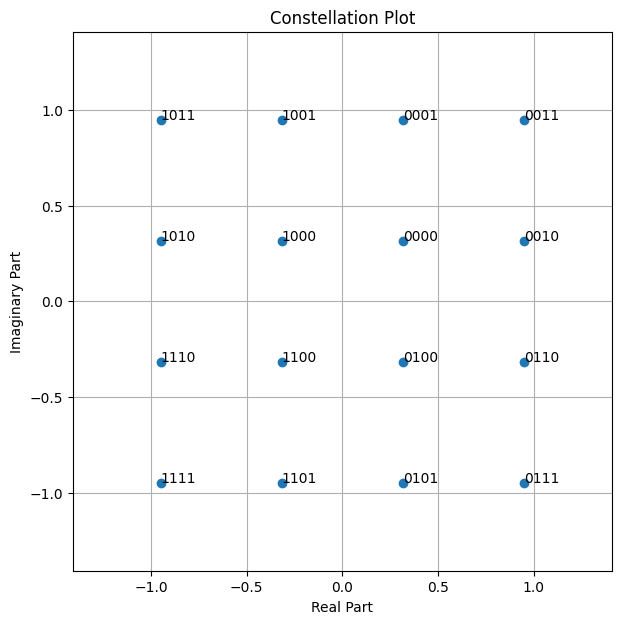

In [3]:
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
constellation.show();

We now need a [Mapper](https://nvlabs.github.io/sionna/phy/api/mapping/Mapper.html) that maps each row of b to the constellation symbols according to the bit labeling shown above.

In [4]:
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
x = mapper(b)
x[:10]

tensor([[ 0.9487+0.9487j],
        [-0.3162-0.3162j],
        [-0.9487-0.3162j],
        [ 0.9487-0.3162j],
        [ 0.3162-0.9487j],
        [ 0.3162-0.9487j],
        [-0.3162+0.3162j],
        [ 0.9487+0.9487j],
        [ 0.3162+0.3162j],
        [ 0.3162-0.3162j]], device='cuda:0')

Let us now make things a bit more interesting a send our symbols over and [AWGN channel](https://nvlabs.github.io/sionna/phy/api/channel/wireless/awgn.html#sionna.phy.channel.AWGN):

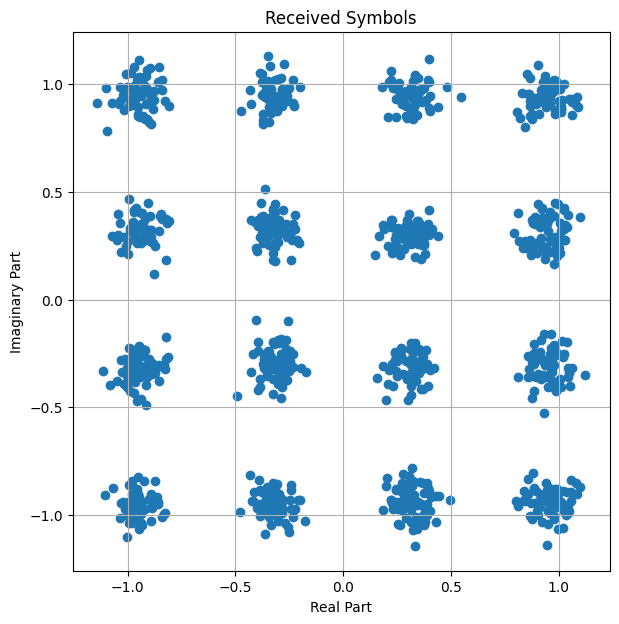

In [5]:
awgn = sionna.phy.channel.AWGN()
ebno_db = 15 # Desired Eb/No in dB
no = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate=1)
y = awgn(x, no).cpu().numpy()

# Visualize the received signal
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.scatter(np.real(y), np.imag(y));
ax.set_aspect("equal", adjustable="box")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True, which="both", axis="both")
plt.title("Received Symbols");